In [ ]:
import glob
import cv2
import numpy as np
import voxelmorph as vxm
import tf2onnx
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model, Input



2025-06-25 20:42:25.612277: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-25 20:42:25.612324: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-25 20:42:25.613493: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


KeyboardInterrupt: 

In [ ]:
pairs = np.load("/home/j/FPGA-project/voxelmorph/data/ixi_pairs.npz")
moving = pairs["moving"]
fixed = pairs["fixed"]
zeros = pairs["zeros"]

print("Loaded pairs:", moving.shape)

Loaded pairs: (2000, 192, 224, 1)


In [ ]:
split = int(0.9 * len(moving))

x_train = [moving[:split], fixed[:split]]
y_train = [fixed[:split], zeros[:split]]

x_val = [moving[split:], fixed[split:]]
y_val = [fixed[split:], zeros[split:]]

print("Train pairs:", x_train[0].shape, "Val pairs:", x_val[0].shape)


Train pairs: (1800, 192, 224, 1) Val pairs: (200, 192, 224, 1)


In [ ]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

In [ ]:
def build_flow_unet(vol_shape, base_filters=32):
    α = 26/256 

    src = Input((*vol_shape, 1))
    tgt = Input((*vol_shape, 1))
    x = layers.Concatenate()([src, tgt])

    e0 = layers.LeakyReLU(alpha=α)(layers.Conv2D(base_filters, 3, padding='same')(x))
    p0 = layers.MaxPooling2D()(e0)

    e1 = layers.LeakyReLU(alpha=α)(layers.Conv2D(base_filters, 3, padding='same')(p0))
    p1 = layers.MaxPooling2D()(e1)

    e2 = layers.LeakyReLU(alpha=α)(layers.Conv2D(base_filters, 3, padding='same')(p1))
    p2 = layers.MaxPooling2D()(e2)

    e3 = layers.LeakyReLU(alpha=α)(layers.Conv2D(base_filters, 3, padding='same')(p2))
    p3 = layers.MaxPooling2D()(e3)


    d3 = layers.LeakyReLU(alpha=α)(layers.Conv2D(base_filters, 3, padding='same')(p3))
    u3 = layers.Concatenate()([layers.UpSampling2D()(d3), e3])

    d2 = layers.LeakyReLU(alpha=α)(layers.Conv2D(base_filters, 3, padding='same')(u3))
    u2 = layers.Concatenate()([layers.UpSampling2D()(d2), e2])

    d1 = layers.LeakyReLU(alpha=α)(layers.Conv2D(base_filters, 3, padding='same')(u2))
    u1 = layers.Concatenate()([layers.UpSampling2D()(d1), e1])

    d0 = layers.LeakyReLU(alpha=α)(layers.Conv2D(base_filters, 3, padding='same')(u1))
    u0 = layers.Concatenate()([layers.UpSampling2D()(d0), e0])

    f0  = layers.LeakyReLU(alpha=α)(layers.Conv2D(base_filters, 3, padding='same')(u0))
    f1  = layers.LeakyReLU(alpha=α)(layers.Conv2D(base_filters//2, 3, padding='same')(f0))
    pad = layers.LeakyReLU(alpha=α)(layers.Conv2D(16, 3, padding='same')(f1))
    flow = layers.Lambda(lambda z: z[..., :2], name='flow')(pad)

    st   = vxm.layers.SpatialTransformer(vol_shape)
    st.interp_method = 'linear'   
    warp = st([src, flow])

    return Model([src, tgt], [warp, flow], name='vxm_dense_unet')

In [ ]:
vol_shape = moving.shape[1:-1]
vxm_model = build_flow_unet(vol_shape)

vxm_model.compile(
    optimizer='adam',
    loss=[ 'mse', vxm.losses.Grad('l2').loss ],
    loss_weights=[1.0, 0.01]
)

vxm_model.summary()

Model: "vxm_dense_unet"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_23 (InputLayer)       [(None, 192, 224, 1)]        0         []                            
                                                                                                  
 input_24 (InputLayer)       [(None, 192, 224, 1)]        0         []                            
                                                                                                  
 concatenate_55 (Concatenat  (None, 192, 224, 2)          0         ['input_23[0][0]',            
 e)                                                                  'input_24[0][0]']            
                                                                                                  
 conv2d_121 (Conv2D)         (None, 192, 224, 32)         608       ['concatenate_55[

In [ ]:
history = vxm_model.fit(
    x_train,
    y_train,
    batch_size=8,
    epochs=50,
    validation_data=(x_val, y_val)  
)

Epoch 1/50
225/225 [==============================] - 14s 51ms/step - loss: 0.0209 - spatial_transformer_4_loss: 0.0194 - flow_loss: 0.1543 - val_loss: 0.0155 - val_spatial_transformer_4_loss: 0.0134 - val_flow_loss: 0.2041
Epoch 2/50
225/225 [==============================] - 10s 46ms/step - loss: 0.0145 - spatial_transformer_4_loss: 0.0123 - flow_loss: 0.2215 - val_loss: 0.0134 - val_spatial_transformer_4_loss: 0.0112 - val_flow_loss: 0.2228
Epoch 3/50
225/225 [==============================] - 10s 46ms/step - loss: 0.0132 - spatial_transformer_4_loss: 0.0110 - flow_loss: 0.2220 - val_loss: 0.0124 - val_spatial_transformer_4_loss: 0.0102 - val_flow_loss: 0.2191
Epoch 4/50
225/225 [==============================] - 11s 47ms/step - loss: 0.0126 - spatial_transformer_4_loss: 0.0104 - flow_loss: 0.2210 - val_loss: 0.0121 - val_spatial_transformer_4_loss: 0.0097 - val_flow_loss: 0.2389
Epoch 5/50
225/225 [==============================] - 11s 47ms/step - loss: 0.0120 - spatial_transformer

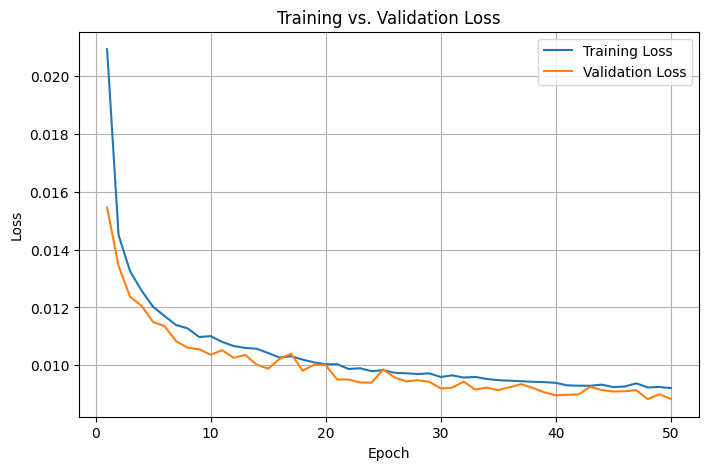

In [ ]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs. Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
vxm_model.save('models/vxm2d_model_ez.h5')

/home/j/miniconda3/envs/gen/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf

slice = np.load('../../workspace/calibration_dataset/calib_pair_0.npy')

mov_ex = slice[0]  
fix_ex = slice[1]

vxm_model = tf.keras.models.load_model('models/vxm2d_model_ez.h5')

warp_pred, flow_pred = vxm_model.predict([mov_ex, fix_ex])
flow_pred = flow_pred[0]  

h, w = flow_pred.shape[:2]
grid_x, grid_y = np.meshgrid(np.arange(w), np.arange(h))
map_x = (grid_x + flow_pred[...,1]).astype(np.float32)
map_y = (grid_y + flow_pred[...,0]).astype(np.float32)
warped = cv2.remap(
    mov_ex[0,...,0],
    map_x, map_y,
    interpolation=cv2.INTER_LINEAR,
    borderMode=cv2.BORDER_REFLECT
)
u = flow_pred[...,0]
v = flow_pred[...,1]

step = 8
x = np.arange(0, w, step)
y = np.arange(0, h, step)
X, Y = np.meshgrid(x, y)
U = u[::step, ::step]
V = v[::step, ::step]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(mov_ex[0,...,0], cmap='gray')
plt.title('Moving'); plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(fix_ex[0,...,0], cmap='gray')
plt.title('Fixed'); plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(warped, cmap='gray')
plt.quiver(
    X, Y, U, V,
    angles='xy', scale_units='xy', scale=1,
    color='r', width=0.003, headwidth=3,
    headlength=4, alpha=0.8
)
plt.title('Warped with Flow'); plt.axis('off')

plt.tight_layout()
plt.show()

2025-06-26 21:20:58.236435: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-26 21:20:58.236515: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-26 21:20:58.236602: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


ValueError: Unknown layer: 'SpatialTransformer'. Please ensure you are using a `keras.utils.custom_object_scope` and that this object is included in the scope. See https://www.tensorflow.org/guide/keras/save_and_serialize#registering_the_custom_object for details.